In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("expectation_decider_dataset.csv")
df.head()

,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,1,8,96,No,87,Pass
1,2,5,92,Yes,68,Fail
2,3,14,45,Yes,43,Pass
3,4,12,67,No,34,Pass
4,5,9,67,Yes,64,Fail


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   student_id           200 non-null    int64 
 1   study_hours          200 non-null    int64 
 2   attendance           200 non-null    int64 
 3   group_discussion     200 non-null    object
 4   previous_test_score  200 non-null    int64 
 5   final_exam_pass      200 non-null    object
dtypes: int64(4), object(2)
memory usage: 9.5+ KB


In [4]:
df.shape

(200, 6)

<h1>TASK 1</h1>

--> What is Probability?

Probability is the measure of the likelihood that an event will occur.

Formula:

P(E) = Total Outcomes / Favourable Outcomes
	
---------------------------------------------------------------------------------------

--> Key Probability Terminology

Define key terms like Sample Space (all possible outcomes), Event (a specific subset of outcomes), and Complement (the probability of an event not occurring).

---------------------------------------------------------------------------------------

--> Probability Events from Dataset

Event A:

Student studies more than 10 hours.

Event B:

Student attendance is above 80%.

Event C:

Student passes final exam.

---------------------------------------------------------------------------------------

<h1>TASK 2</h1>

--> Empirical Probability

Probability based on actual observed data.

Formula:

P(E) = Total Observations / Observed Frequency

--> Theoretical Probability

Probability based on assumptions rather than collected data.

Formula:

P(E) = Possible Outcomes / Favourable Outcomes

-------------------------------------------------------------------------------------

In [5]:
#Empirical Probability
#Probability of passing.

total_students = len(df)
passed_students  = (df['final_exam_pass'] == "Pass").sum()
empirical_probability = passed_students / total_students

print("Total Students =", total_students)
print("Passed Students =", passed_students)
print("Empirical Probability =", empirical_probability)

Total Students = 200
Passed Students = 118
Empirical Probability = 0.59


------------------------------------------------------------------------------------------
Mathematical Calculation
P(Pass)=118 / 200

P(Pass)=0.59

P(Pass)=59%

The empirical probability indicates that based on actual observed data, approximately 59% of students passed the competitive examination.

In [6]:
#Theoretical Probability
#Possible outcomes: {Pass,Fail}
#Number of favorable outcomes for Pass = 1

theoretical_probability = 1/2

print("Theoretical Probability =", theoretical_probability)

Theoretical Probability = 0.5


------------------------------------------------------------------------------------------
Mathematical Calculation
P(Pass)=1 / 2

P(Pass)=0.5

P(Pass)=50%

The theoretical probability assumes that pass and fail are equally likely outcomes. Under this assumption, the probability of passing is 50%.

<h1>TASK 3</h1>

--> What is a Random Variable?

A random variable is a numerical value assigned to the outcome of a random experiment.

Usually represented by:

X

---------------------------------------------------------------------------------------

In [7]:
passed_students = (df['final_exam_pass'] == 'Pass').sum()
total_students = len(df)

p = passed_students / total_students
q = 1 - p

print("Probability of Pass =", p)
print("Probability of Fail =", q)

Probability of Pass = 0.59
Probability of Fail = 0.41000000000000003


---------------------------------------------------------------------------------------------
--> Probability Distribution

A probability distribution shows:

Possible values of X
Probability associated with each value

X     = 0, 1, 2, 3

P(X)  = P(X=0), P(X=1), P(X=2), P(X=3)

------------------------------------------------------------------------------------------

In [8]:
#probabilities 
px0 = q*q*q
px1 = p*q*q + q*p*q + q*q*p
px2 = p*p*q + p*q*p + q*p*p
px3 = p*p*p

print(px0)
print(px1)
print(px2)
print(px3)

0.06892100000000001
0.29753700000000005
0.42816299999999996
0.20537899999999998


In [9]:
distribution = pd.DataFrame({
    "X":[0,1,2,3],
    "P(X)":[px0,px1,px2,px3]
})

distribution

,X,P(X)
0,0,0.068921
1,1,0.297537
2,2,0.428163
3,3,0.205379


In [10]:
mean = ( 0*px0 + 1*px1 + 2*px2 + 3*px3 )

print(mean)

1.7699999999999998


In [11]:
variance = (
    ((0-mean)**2)*px0 +
    ((1-mean)**2)*px1 +
    ((2-mean)**2)*px2 +
    ((3-mean)**2)*px3
)

print(variance)

0.7257


<h1>TASK 4</h1>

In [12]:
study = df[df['study_hours'] > 10]
print("Students studying more than 10 hours:", len(study))

attendance = df[df['attendance'] > 80]
print("Students with attendance above 80%:", len(attendance))

both = df[(df['study_hours'] > 10) & (df['attendance'] > 80)]
print("Students satisfying both conditions:", len(both))

Students studying more than 10 hours: 79
Students with attendance above 80%: 63
Students satisfying both conditions: 25


In [15]:
pip install matplotlib-venn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45440 sha256=4bb365df4ca60973e0e923faf73c281264e49ce0542b8ad836969c484c473e12
  Stored in directory: c:\users\devanshi kanthariya\appdata\local\pip\cache\wheels\d1\5f\e6\771479559f992b8398265ebf61f8a3d33ca0b8f75552e06ad2
Successfully built matplotlib-venn
Note: you may need to restart the kernel to use updated packages.


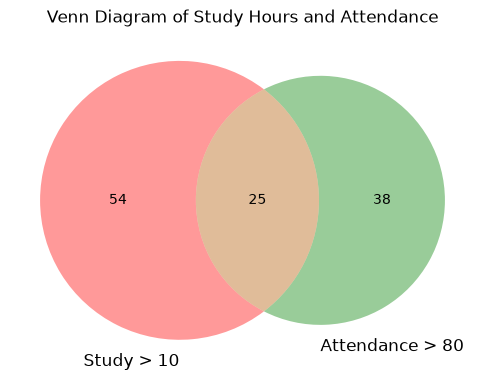

In [16]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

only_study = len(study) - len(both)
only_attendance = len(attendance) - len(both)

plt.figure(figsize=(6,6))

venn2(
    subsets=(only_study, only_attendance, len(both)),
    set_labels=('Study > 10', 'Attendance > 80')
)

plt.title("Venn Diagram of Study Hours and Attendance")

plt.show()

<h1>TASK 5</h1>

In [17]:
contingency_table = pd.crosstab(
    df['group_discussion'],
    df['final_exam_pass']
)

contingency_table

final_exam_pass,Fail,Pass
group_discussion,,
No,44,31
Yes,38,87


In [18]:
joint_probability = (
    contingency_table.loc['Yes','Pass']
    / len(df)
)

print(joint_probability)

0.435


In [20]:
passed_students = (df['final_exam_pass'] == 'Pass').sum()
marginal_probability = passed_students / len(df)
print(marginal_probability)

0.59


In [21]:
discussion_students = contingency_table.loc['Yes'].sum()
pass_and_discussion = contingency_table.loc['Yes','Pass']
conditional_probability = (pass_and_discussion / discussion_students)
print(conditional_probability)

0.696


<h1>TASK 6</h1>

In [24]:
print("P(Pass) =", marginal_probability)
print("P(Pass|Discussion) =", conditional_probability)

P(Pass) = 0.59
P(Pass|Discussion) = 0.696


In [25]:
if conditional_probability == marginal_probability:
    print("Independent Events")
else:
    print("Dependent Events")

Dependent Events


--------------------------------------------------------------------------------------
P(Pass)=0.59
P(Pass∣Discussion)=0.696
0.696!=0.59

the probability of passing changes when we know that a student participated in group discussions.

Therefore:

Group discussion participation and passing the exam are Dependent Events.

-------------------------------------------------------------------------------------

<h1>TASK 7</h1>

In [26]:
p_h_given_p = 0.70

p_h_given_f = 0.40

p_h = 0.60

p_p = len(
    df[df['final_exam_pass'] == 'Pass']
) / len(df)

print(p_p)

0.59


In [27]:
bayes_probability = (
    p_h_given_p * p_p
) / p_h

print(bayes_probability)

0.6883333333333334


In [28]:
print("Probability =", round(bayes_probability,4))
print("Percentage =", round(bayes_probability*100,2), "%")

Probability = 0.6883
Percentage = 68.83 %


------------------------------------------------------------------------------------------
The probability that a student passed the final examination given that they had attendance greater than 80% is approximately:

68.83%

This suggests that students with high attendance are more likely to pass the examination.